# Experiment 4 — Class Imbalance & Minority Class Handling
## Can we improve Active class detection under severe label scarcity?

| | |
|---|---|
| **Problem** | Active class has only 34 images (8.3%) — at 5% labels, just 1 Active training image |
| **Model** | ConvNeXt-Base (best from E1) with best augmentation (Colour-Only at 5–10%, CLAHE at 25%) |
| **Label fractions** | 5% · 10% · 25% · 50% · 100% |
| **Strategies tested** | 4 loss/sampling strategies for minority class handling |
| **Primary metric** | Active class F1-score (minority class) + Macro AUC-ROC |

### Strategies
| ID | Name | Description |
|---|---|---|
| S1 | **Weighted CE** | Inverse-frequency class weights (E1 baseline) |
| S2 | **Focal Loss** | FL(p) = −(1−p)^γ log(p), γ=2. Down-weights easy negatives |
| S3 | **Oversampling** | Repeat Active+Inactive images in training set to balance classes |
| S4 | **Prototype Classifier** | Replace linear head with nearest-centroid (prototype) classifier |
| S5 | **Label Smoothing** | CE with label smoothing ε=0.1 — prevents overconfidence on rare class |

### Why Active class matters clinically
Active ocular toxoplasmosis requires urgent treatment. Missing an active case (false negative) is far more dangerous than a false positive. Sensitivity on the Active class is therefore the most clinically important metric in this paper.

---

## Cell 1 — Install & Imports

In [1]:
import subprocess
def run(cmd):
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    print(('[OK] ' if r.returncode==0 else '[WARN] ') + cmd)
    if r.returncode != 0 and r.stderr: print('  ', r.stderr[:200])

run('pip install -q timm==1.0.3 scikit-learn matplotlib seaborn pandas numpy Pillow tqdm opencv-python-headless')

import os, random, warnings, copy
from pathlib import Path
from copy import deepcopy
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from PIL import Image
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
import torchvision.models as tv_models

from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,
                              classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
SEED = 42
def set_seed(s=SEED):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed()

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}  |  GPU : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')
print('Imports OK.')

[OK] pip install -q timm==1.0.3 scikit-learn matplotlib seaborn pandas numpy Pillow tqdm opencv-python-headless
Device : cuda  |  GPU : Tesla T4
Imports OK.


## Cell 2 — Config & Paths

In [2]:
DS1_ROOT    = Path('/kaggle/input/datasets/nafin59/ocular-toxoplasmosis-fundus-images-dataset')
DS2_ROOT    = Path('/kaggle/input/datasets/sakibapon/ocular-toxoplasmosis')
DIR_6CLASS  = DS1_ROOT / 'Data_Raw_6class_All' / 'Data_Raw_6class_All'
DIR_V2      = DS2_ROOT / 'Dataset V2' / 'classification'

EXTS        = {'.jpg','.jpeg','.png','.bmp','.tiff'}
LABEL_FRACS = [0.05, 0.10, 0.25, 0.50, 1.00]
EPOCHS      = 30
BATCH_SIZE  = 16
IMG_SIZE    = 224
LR          = 3e-4
WEIGHT_DECAY= 0.05
PATIENCE    = 7

CLASS_NAMES = ['Healthy', 'Active', 'Inactive']
NUM_CLASSES = 3
PALETTE     = ['#4CAF50','#E53935','#1E88E5']
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

# Best augmentation from E3 per fraction
# 5%  → Colour-Only
# 10% → Colour-Only
# 25% → CLAHE + Geo
# 50% → CLAHE + Geo (extrapolating E3 trend)
# 100%→ CLAHE + Geo

def apply_clahe(img, clip=2.0, tile=(8,8)):
    arr = np.array(img)
    c   = cv2.createCLAHE(clipLimit=clip, tileGridSize=tile)
    return Image.fromarray(np.stack([c.apply(arr[:,:,i]) for i in range(3)], axis=2))

class CLAHETransform:
    def __call__(self, img): return apply_clahe(img)

_norm = T.Compose([T.ToTensor(), T.Normalize(MEAN, STD)])

TFM_COLOR = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),
    T.RandomAutocontrast(p=0.3),
    _norm,
])
TFM_CLAHE = T.Compose([
    T.Resize((IMG_SIZE+32, IMG_SIZE+32)),
    CLAHETransform(),
    T.RandomCrop(IMG_SIZE),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(15),
    _norm,
])
VAL_TFM = T.Compose([T.Resize((IMG_SIZE,IMG_SIZE)), _norm])

def best_tfm(frac):
    return TFM_COLOR if frac <= 0.10 else TFM_CLAHE

print('Config ready.')

Config ready.


## Cell 3 — Build DataFrames & Splits

In [3]:
FOLDER_TO_LABEL = {
    'healthy':0,'active':1,'active_active':1,
    'inactive':2,'inactive_inactive':2,'active_inactive':2,
}

def build_df():
    rows=[]
    for folder,label in FOLDER_TO_LABEL.items():
        d=DIR_6CLASS/folder
        if not d.exists(): continue
        for p in d.iterdir():
            if p.suffix.lower() in EXTS:
                rows.append({'path':str(p),'label':label,'src':folder})
    return pd.DataFrame(rows).sample(frac=1,random_state=SEED).reset_index(drop=True)

def build_v2_df():
    rows=[]
    v2_map={'healthy':0,'health':0,'non_healthy':1,'inactive':1,'diseased':1,'active':1}
    for sp in sorted(DIR_V2.iterdir()):
        if not sp.is_dir(): continue
        for cd in sorted(sp.iterdir()):
            if not cd.is_dir(): continue
            label=v2_map.get(cd.name.lower())
            if label is None: continue
            for p in cd.iterdir():
                if p.suffix.lower() in EXTS:
                    rows.append({'path':str(p),'label_bin':label})
    return pd.DataFrame(rows).sample(frac=1,random_state=SEED).reset_index(drop=True)

df    = build_df()
v2_df = build_v2_df()

train_df,temp_df = train_test_split(df, test_size=0.40, stratify=df['label'], random_state=SEED)
val_df,test_df   = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=SEED)
train_df=train_df.reset_index(drop=True); val_df=val_df.reset_index(drop=True); test_df=test_df.reset_index(drop=True)
_,v2_test_df = train_test_split(v2_df, test_size=0.80, stratify=v2_df['label_bin'], random_state=SEED)

print(f'Primary: {len(df)}  Train={len(train_df)} Val={len(val_df)} Test={len(test_df)}')
print('Class distribution:')
for i,n in enumerate(CLASS_NAMES):
    c=(df['label']==i).sum()
    print(f'  {n:10s}: {c:4d} total  |  Train: {(train_df["label"]==i).sum():3d}  '
          f'Val: {(val_df["label"]==i).sum():2d}  Test: {(test_df["label"]==i).sum():2d}')
print(f'\nIMBALANCE: Active is {100*(df["label"]==1).sum()/len(df):.1f}% of total dataset')

Primary: 411  Train=246 Val=82 Test=83
Class distribution:
  Healthy   :  132 total  |  Train:  79  Val: 26  Test: 27
  Active    :   34 total  |  Train:  20  Val:  7  Test:  7
  Inactive  :  245 total  |  Train: 147  Val: 49  Test: 49

IMBALANCE: Active is 8.3% of total dataset


## Cell 4 — Dataset Classes & Samplers

In [4]:
class OTDataset(Dataset):
    def __init__(self, df, label_col='label', transform=None):
        self.df=df.reset_index(drop=True); self.label_col=label_col; self.transform=transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row=self.df.iloc[idx]
        img=Image.open(row['path']).convert('RGB')
        if self.transform: img=self.transform(img)
        return img, int(row[self.label_col])

def make_weighted_sampler(subset_df):
    """WeightedRandomSampler: samples each class with equal probability per epoch."""    
    counts = np.array([(subset_df['label']==i).sum() for i in range(NUM_CLASSES)], dtype=float)
    counts = np.where(counts==0, 1, counts)
    weights_per_class = 1.0 / counts
    sample_weights = np.array([weights_per_class[int(l)] for l in subset_df['label']])
    return WeightedRandomSampler(
        weights=torch.tensor(sample_weights, dtype=torch.float64),
        num_samples=len(subset_df), replacement=True
    )

def oversample_minority(subset_df, target_ratio=0.25):
    """
    Duplicate Active+Inactive rows until Active is at least target_ratio of dataset.
    Strategy: repeat the entire Active subset until balance is reached.
    """
    active_df   = subset_df[subset_df['label']==1]
    inactive_df = subset_df[subset_df['label']==2]
    healthy_df  = subset_df[subset_df['label']==0]

    if len(active_df)==0:
        return subset_df   # can't oversample if no Active present

    n_total  = len(subset_df)
    n_active = len(active_df)
    # How many times to repeat Active to reach target_ratio
    needed   = max(1, int(np.ceil(target_ratio * n_total / max(n_active, 1))))
    active_os = pd.concat([active_df]*needed, ignore_index=True)

    result = pd.concat([healthy_df, active_os, inactive_df], ignore_index=True)
    result = result.sample(frac=1, random_state=SEED).reset_index(drop=True)
    return result

# Fixed loaders
val_loader  = DataLoader(OTDataset(val_df, 'label', VAL_TFM), batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)
test_loader = DataLoader(OTDataset(test_df,'label', VAL_TFM), batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)
v2_loader   = DataLoader(OTDataset(v2_test_df,'label_bin',VAL_TFM), batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)
print('Dataset classes and fixed loaders ready.')

Dataset classes and fixed loaders ready.


## Cell 5 — Loss Functions

In [5]:
# ── S1: Weighted Cross-Entropy (E1 baseline) ─────────────────────────────────
def get_weighted_ce(subset_df):
    counts=np.array([(subset_df['label']==i).sum() for i in range(NUM_CLASSES)],dtype=float)
    counts=np.where(counts==0,1,counts); w=1.0/counts
    return nn.CrossEntropyLoss(weight=torch.tensor(w/w.sum()*NUM_CLASSES,dtype=torch.float32).to(DEVICE))

# ── S2: Focal Loss ────────────────────────────────────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        super().__init__()
        self.gamma  = gamma
        self.weight = weight
    def forward(self, logits, labels):
        ce   = F.cross_entropy(logits, labels, weight=self.weight, reduction='none')
        pt   = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        return loss.mean()

def get_focal_loss(subset_df, gamma=2.0):
    counts=np.array([(subset_df['label']==i).sum() for i in range(NUM_CLASSES)],dtype=float)
    counts=np.where(counts==0,1,counts); w=1.0/counts
    w_tensor=torch.tensor(w/w.sum()*NUM_CLASSES,dtype=torch.float32).to(DEVICE)
    return FocalLoss(gamma=gamma, weight=w_tensor)

# ── S5: Label Smoothing CE ────────────────────────────────────────────────────
def get_label_smoothing_ce(subset_df, smoothing=0.1):
    counts=np.array([(subset_df['label']==i).sum() for i in range(NUM_CLASSES)],dtype=float)
    counts=np.where(counts==0,1,counts); w=1.0/counts
    w_tensor=torch.tensor(w/w.sum()*NUM_CLASSES,dtype=torch.float32).to(DEVICE)
    return nn.CrossEntropyLoss(weight=w_tensor, label_smoothing=smoothing)

print('Loss functions defined:')
print('  S1: Weighted Cross-Entropy')
print('  S2: Focal Loss (γ=2.0)')
print('  S3: Oversampling + Weighted CE')
print('  S4: Prototype Classifier')
print('  S5: Label Smoothing CE (ε=0.1)')

Loss functions defined:
  S1: Weighted Cross-Entropy
  S2: Focal Loss (γ=2.0)
  S3: Oversampling + Weighted CE
  S4: Prototype Classifier
  S5: Label Smoothing CE (ε=0.1)


## Cell 6 — Model Builder (ConvNeXt-Base)

In [6]:
def build_convnext(num_classes, prototype=False):
    m = tv_models.convnext_base(weights=tv_models.ConvNeXt_Base_Weights.IMAGENET1K_V1)
    in_features = m.classifier[2].in_features

    if prototype:
        # Replace linear head with prototype-based nearest-centroid classifier
        class ProtoHead(nn.Module):
            def __init__(self, embed_dim, nc):
                super().__init__()
                self.embed_dim = embed_dim
                self.nc        = nc
                # Learnable prototypes — one per class
                self.prototypes = nn.Parameter(torch.randn(nc, embed_dim))
                nn.init.xavier_uniform_(self.prototypes.unsqueeze(0))
            def forward(self, x):
                # x: [B, embed_dim]
                # Compute negative squared Euclidean distance to each prototype
                dists = torch.cdist(x, self.prototypes)  # [B, nc]
                return -dists   # higher = closer = more likely

        m.classifier[2] = ProtoHead(in_features, num_classes)
        print(f'  ConvNeXt-Base (Prototype head) ready | embed_dim={in_features}')
    else:
        m.classifier[2] = nn.Linear(in_features, num_classes)
        print(f'  ConvNeXt-Base (Linear head) ready')
    return m

print('Model builder defined.')

Model builder defined.


## Cell 7 — Training & Evaluation Helpers

In [7]:
def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train(); total_loss=correct=total=0
    for imgs,labels in loader:
        imgs,labels=imgs.to(DEVICE),labels.to(DEVICE)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            out=model(imgs); loss=criterion(out,labels)
        scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        total_loss+=loss.item()*len(labels)
        correct+=(out.argmax(1)==labels).sum().item(); total+=len(labels)
    return total_loss/total, correct/total

@torch.no_grad()
def evaluate_3class(model, loader):
    model.eval(); all_logits,all_labels=[],[]
    for imgs,labels in loader:
        all_logits.append(model(imgs.to(DEVICE)).cpu()); all_labels.append(labels)
    logits=torch.cat(all_logits); labels=torch.cat(all_labels).numpy()
    probs=torch.softmax(logits,1).numpy(); preds=logits.argmax(1).numpy()
    acc=accuracy_score(labels,preds)
    macro_f1=f1_score(labels,preds,average='macro',zero_division=0)
    active_f1=f1_score(labels,preds,labels=[1],average='macro',zero_division=0)
    active_recall=np.sum((preds==1)&(labels==1))/max(np.sum(labels==1),1)
    try: auc=roc_auc_score(labels,probs,multi_class='ovr',average='macro')
    except: auc=float('nan')
    return acc, macro_f1, auc, active_f1, active_recall, preds, labels

@torch.no_grad()
def evaluate_binary(model, loader):
    model.eval(); all_logits,all_labels=[],[]
    for imgs,labels in loader:
        all_logits.append(model(imgs.to(DEVICE)).cpu()); all_labels.append(labels)
    logits=torch.cat(all_logits); labels=torch.cat(all_labels).numpy()
    disease_prob=1.0-torch.softmax(torch.cat(all_logits),1).numpy()[:,0]
    try: auc=roc_auc_score(labels, disease_prob)
    except: auc=float('nan')
    return auc

def train_and_eval(subset_df, strategy_name, frac, train_tfm):
    """Train ConvNeXt-Base with a given imbalance strategy and evaluate."""    
    set_seed(SEED)

    is_proto    = (strategy_name == 'S4_Proto')
    is_oversamp = (strategy_name == 'S3_OverSamp')

    model = build_convnext(NUM_CLASSES, prototype=is_proto).to(DEVICE)

    # ── Data setup ─────────────────────────────────────────────────────────────
    if is_oversamp:
        train_sub = oversample_minority(subset_df, target_ratio=0.25)
        print(f'    Oversampled: {len(subset_df)}→{len(train_sub)} '
              f'(Active: {(subset_df["label"]==1).sum()}→{(train_sub["label"]==1).sum()})')
    else:
        train_sub = subset_df

    train_ds = OTDataset(train_sub, 'label', train_tfm)

    # WeightedRandomSampler for S3 ensures balanced batches
    if is_oversamp:
        sampler  = make_weighted_sampler(train_sub)
        train_ld = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                               num_workers=2, pin_memory=True)
    else:
        train_ld = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                               num_workers=2, pin_memory=True,
                               drop_last=len(train_ds)>=BATCH_SIZE)

    # ── Loss function ──────────────────────────────────────────────────────────
    if strategy_name   == 'S1_WeightedCE':  criterion = get_weighted_ce(subset_df)
    elif strategy_name == 'S2_FocalLoss':   criterion = get_focal_loss(subset_df, gamma=2.0)
    elif strategy_name == 'S3_OverSamp':    criterion = get_weighted_ce(train_sub)
    elif strategy_name == 'S4_Proto':       criterion = get_weighted_ce(subset_df)
    elif strategy_name == 'S5_LabelSmooth': criterion = get_label_smoothing_ce(subset_df, smoothing=0.1)

    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    scaler    = torch.cuda.amp.GradScaler()

    best_auc=0.0; best_state=None; wait=0

    for epoch in range(1, EPOCHS+1):
        train_one_epoch(model, train_ld, criterion, optimizer, scaler)
        _,_,val_auc,*_ = evaluate_3class(model, val_loader)
        scheduler.step()
        if val_auc > best_auc:
            best_auc=val_auc; best_state=deepcopy(model.state_dict()); wait=0
        else:
            wait+=1
            if wait >= PATIENCE: break

    model.load_state_dict(best_state)
    acc,macro_f1,auc,active_f1,active_recall,preds,labels = evaluate_3class(model, test_loader)
    ext_auc = evaluate_binary(model, v2_loader)

    del model; torch.cuda.empty_cache()
    return acc, macro_f1, auc, active_f1, active_recall, ext_auc, preds, labels

print('Training helpers defined.')

Training helpers defined.


## Cell 8 — Run Experiment 4

> **Estimated runtime:** ~1.5–2 hrs  
> 5 strategies × 5 fractions = 25 runs, ConvNeXt-Base only

In [8]:
STRATEGIES = {
    'S1_WeightedCE' : 'Weighted CE (Baseline)',
    'S2_FocalLoss'  : 'Focal Loss (γ=2)',
    'S3_OverSamp'   : 'Oversampling',
    'S4_Proto'      : 'Prototype Classifier',
    'S5_LabelSmooth': 'Label Smoothing (ε=0.1)',
}

all_results  = []
best_preds   = {}   # store preds at 100% for confusion matrices

for strat_id, strat_label in STRATEGIES.items():
    print(f'\n{"="*62}')
    print(f'  STRATEGY: {strat_label}')
    print(f'{"="*62}')

    for frac in LABEL_FRACS:
        if frac < 1.0:
            sub_df,_ = train_test_split(train_df, train_size=frac,
                                         stratify=train_df['label'], random_state=SEED)
        else:
            sub_df = train_df.copy()
        sub_df = sub_df.reset_index(drop=True)

        if sub_df['label'].nunique() < NUM_CLASSES:
            print(f'  [SKIP] {int(frac*100)}%: not all classes represented'); continue

        n_h=(sub_df['label']==0).sum(); n_a=(sub_df['label']==1).sum(); n_i=(sub_df['label']==2).sum()
        train_tfm = best_tfm(frac)
        print(f'\n  {int(frac*100):3d}% | H={n_h} A={n_a} I={n_i}', end=' ... ')

        acc,mf1,auc,act_f1,act_rec,ext_auc,preds,labels = train_and_eval(
            sub_df, strat_id, frac, train_tfm)

        print(f'AUC={auc:.3f}  ActiveF1={act_f1:.3f}  ActiveRec={act_rec:.3f}  ExtAUC={ext_auc:.3f}')

        row = dict(
            Strategy=strat_id, StratLabel=strat_label,
            Fraction=frac, Pct=int(frac*100), N_Train=len(sub_df),
            Test_AUC=round(auc,4), Test_MacroF1=round(mf1,4), Test_ACC=round(acc,4),
            Active_F1=round(act_f1,4), Active_Recall=round(act_rec,4),
            Ext_AUC=round(ext_auc,4),
        )
        all_results.append(row)
        pd.DataFrame(all_results).to_csv('/kaggle/working/experiment4_results.csv',index=False)

        if frac == 1.0:
            best_preds[strat_id] = (preds, labels)

results_df = pd.DataFrame(all_results)
print('\n\n✅ ALL RUNS COMPLETE')
print(results_df[['Strategy','Pct','Test_AUC','Active_F1','Active_Recall','Ext_AUC']].to_string(index=False))


  STRATEGY: Weighted CE (Baseline)

    5% | H=4 A=1 I=7 ... Downloading: "https://download.pytorch.org/models/convnext_base-6075fbad.pth" to /root/.cache/torch/hub/checkpoints/convnext_base-6075fbad.pth


100%|██████████| 338M/338M [00:02<00:00, 144MB/s]


  ConvNeXt-Base (Linear head) ready
AUC=0.898  ActiveF1=0.444  ActiveRec=0.286  ExtAUC=0.969

   10% | H=8 A=2 I=14 ...   ConvNeXt-Base (Linear head) ready
AUC=0.927  ActiveF1=0.600  ActiveRec=0.429  ExtAUC=0.980

   25% | H=20 A=5 I=36 ...   ConvNeXt-Base (Linear head) ready
AUC=0.978  ActiveF1=0.600  ActiveRec=0.429  ExtAUC=1.000

   50% | H=39 A=10 I=74 ...   ConvNeXt-Base (Linear head) ready
AUC=0.983  ActiveF1=0.636  ActiveRec=1.000  ExtAUC=0.998

  100% | H=79 A=20 I=147 ...   ConvNeXt-Base (Linear head) ready
AUC=0.980  ActiveF1=0.700  ActiveRec=1.000  ExtAUC=0.999

  STRATEGY: Focal Loss (γ=2)

    5% | H=4 A=1 I=7 ...   ConvNeXt-Base (Linear head) ready
AUC=0.898  ActiveF1=0.444  ActiveRec=0.286  ExtAUC=0.970

   10% | H=8 A=2 I=14 ...   ConvNeXt-Base (Linear head) ready
AUC=0.894  ActiveF1=0.421  ActiveRec=0.571  ExtAUC=0.977

   25% | H=20 A=5 I=36 ...   ConvNeXt-Base (Linear head) ready
AUC=0.924  ActiveF1=0.500  ActiveRec=0.429  ExtAUC=0.974

   50% | H=39 A=10 I=74 ...   

## Cell 9 — Figure 1: AUC & Active F1 Curves

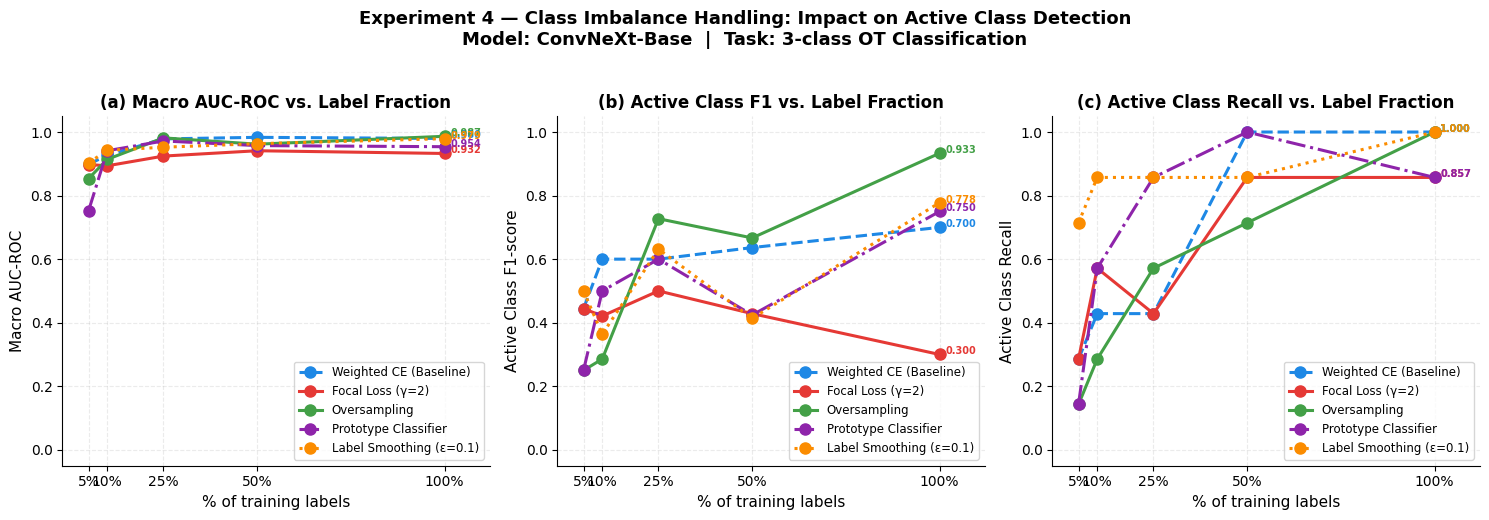

Figure 1 saved.


In [9]:
STRAT_COLORS = {
    'S1_WeightedCE' : '#1E88E5',
    'S2_FocalLoss'  : '#E53935',
    'S3_OverSamp'   : '#43A047',
    'S4_Proto'      : '#8E24AA',
    'S5_LabelSmooth': '#FB8C00',
}
STRAT_LS = {
    'S1_WeightedCE' : '--',
    'S2_FocalLoss'  : '-',
    'S3_OverSamp'   : '-',
    'S4_Proto'      : '-.',
    'S5_LabelSmooth': ':',
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = [
    ('Test_AUC',      'Macro AUC-ROC',        '(a) Macro AUC-ROC vs. Label Fraction'),
    ('Active_F1',     'Active Class F1-score', '(b) Active Class F1 vs. Label Fraction'),
    ('Active_Recall', 'Active Class Recall',   '(c) Active Class Recall vs. Label Fraction'),
]

for ax, (metric, ylabel, title) in zip(axes, metrics):
    for strat_id, strat_label in STRATEGIES.items():
        sub = results_df[results_df['Strategy']==strat_id].sort_values('Fraction')
        if len(sub)==0: continue
        ax.plot(sub['Pct'], sub[metric],
                color=STRAT_COLORS[strat_id], linestyle=STRAT_LS[strat_id],
                linewidth=2.2, marker='o', markersize=8, label=strat_label)
        last = sub[sub['Pct']==100]
        if len(last):
            ax.annotate(f"{last[metric].values[0]:.3f}",
                        xy=(100, last[metric].values[0]), xytext=(4,0),
                        textcoords='offset points', fontsize=7,
                        color=STRAT_COLORS[strat_id], fontweight='bold')

    ax.set_xlabel('% of training labels', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticks([5,10,25,50,100])
    ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%d%%'))
    ax.set_xlim(-2, 112); ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8.5, loc='lower right')
    ax.grid(True, alpha=0.25, linestyle='--')
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Experiment 4 — Class Imbalance Handling: Impact on Active Class Detection\n'
             'Model: ConvNeXt-Base  |  Task: 3-class OT Classification', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('/kaggle/working/e4_fig1_strategies.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

## Cell 10 — Figure 2: AUC & Active F1 Heatmaps

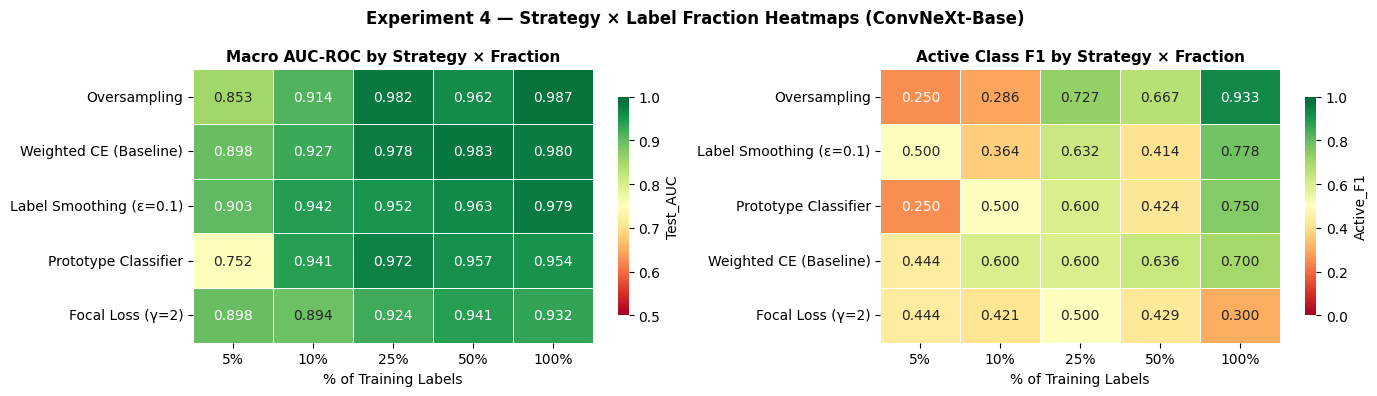

Figure 2 saved.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (metric, title, vmin, vmax) in zip(axes, [
    ('Test_AUC',  'Macro AUC-ROC by Strategy × Fraction', 0.50, 1.00),
    ('Active_F1', 'Active Class F1 by Strategy × Fraction', 0.00, 1.00),
]):
    pivot = results_df.pivot_table(index='StratLabel', columns='Pct', values=metric).round(3)
    pivot.columns = [f'{c}%' for c in pivot.columns]
    pivot = pivot.sort_values('100%', ascending=False)
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn',
                vmin=vmin, vmax=vmax, linewidths=0.6, ax=ax,
                cbar_kws={'label': metric, 'shrink': 0.8})
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('% of Training Labels'); ax.set_ylabel('')

plt.suptitle('Experiment 4 — Strategy × Label Fraction Heatmaps (ConvNeXt-Base)', fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/e4_fig2_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

## Cell 11 — Figure 3: Confusion Matrices @ 100% Labels

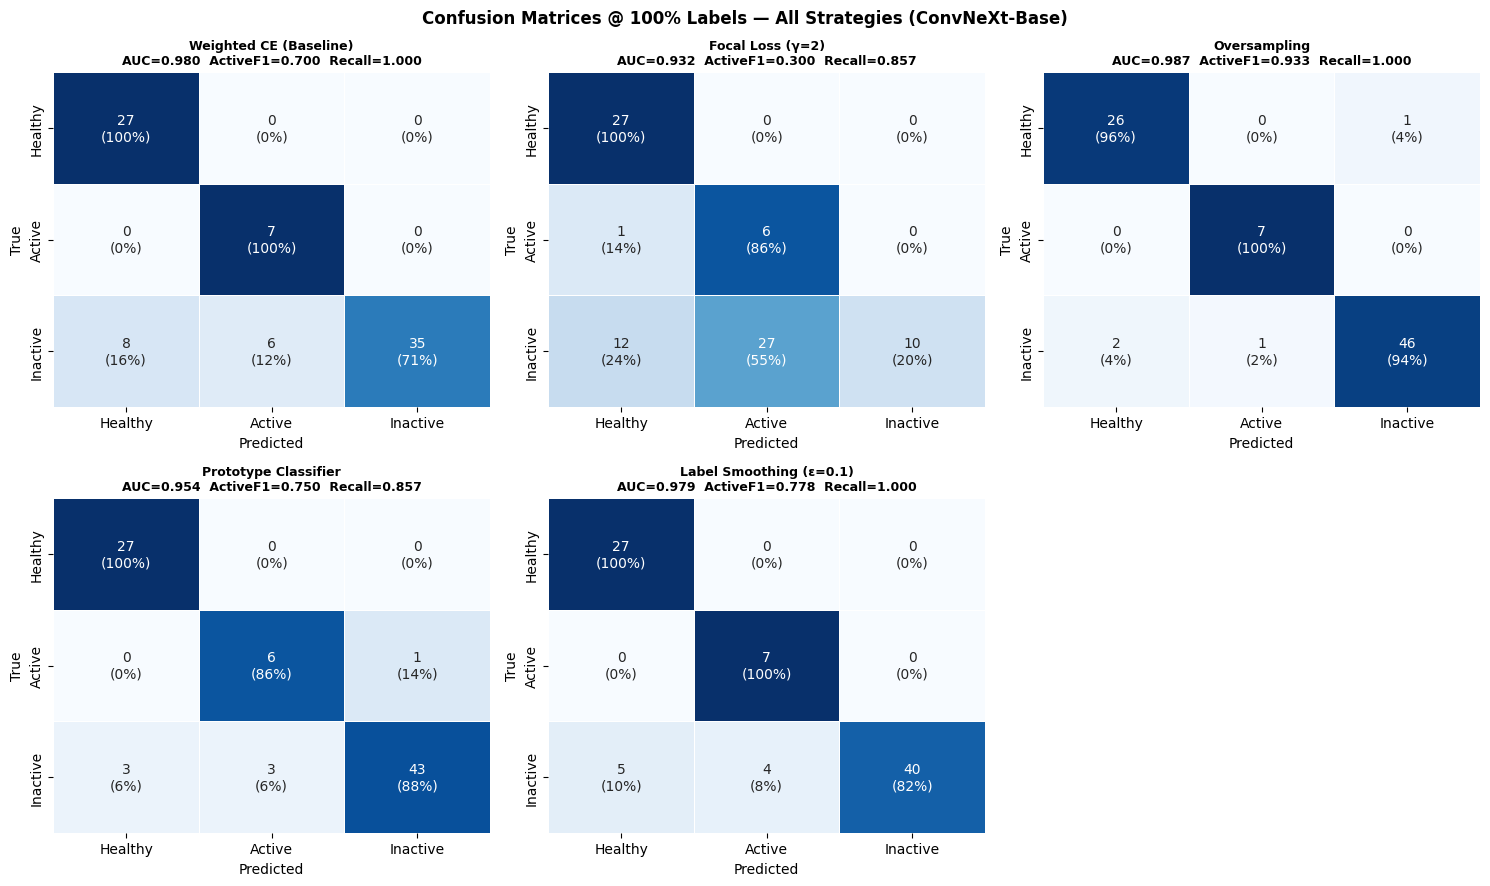

In [11]:
n_s = len(best_preds)
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, (strat_id, (preds, labels)) in zip(axes, best_preds.items()):
    cm      = confusion_matrix(labels, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    annot   = np.array([[f'{cm[i,j]}\n({cm_norm[i,j]:.0%})' for j in range(3)] for i in range(3)])
    sns.heatmap(cm_norm, annot=annot, fmt='', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5, ax=ax, cbar=False, vmin=0, vmax=1)
    r = results_df[(results_df['Strategy']==strat_id)&(results_df['Pct']==100)].iloc[0]
    ax.set_title(f'{STRATEGIES[strat_id]}\n'
                 f'AUC={r.Test_AUC:.3f}  ActiveF1={r.Active_F1:.3f}  Recall={r.Active_Recall:.3f}',
                 fontweight='bold', fontsize=9)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

for ax in axes[n_s:]: ax.set_visible(False)

plt.suptitle('Confusion Matrices @ 100% Labels — All Strategies (ConvNeXt-Base)', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('/kaggle/working/e4_fig3_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 12 — Figure 4: Active Class Analysis

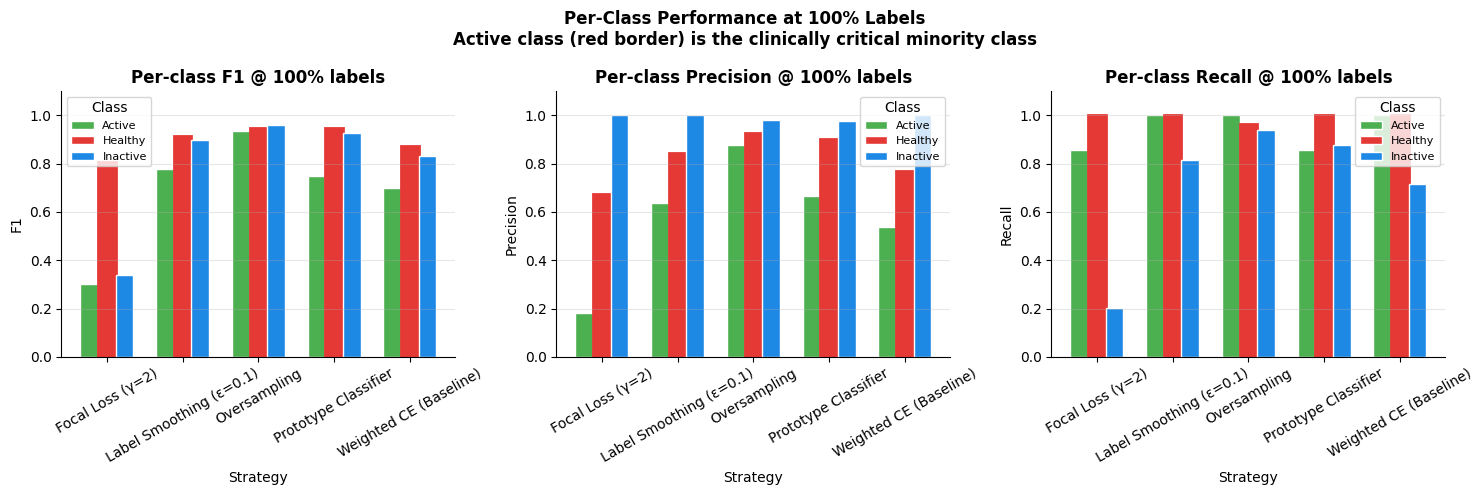


── Per-class classification reports @ 100% ──

── Weighted CE (Baseline) ──
              precision    recall  f1-score   support

     Healthy      0.771     1.000     0.871        27
      Active      0.538     1.000     0.700         7
    Inactive      1.000     0.714     0.833        49

    accuracy                          0.831        83
   macro avg      0.770     0.905     0.801        83
weighted avg      0.887     0.831     0.834        83

── Focal Loss (γ=2) ──
              precision    recall  f1-score   support

     Healthy      0.675     1.000     0.806        27
      Active      0.182     0.857     0.300         7
    Inactive      1.000     0.204     0.339        49

    accuracy                          0.518        83
   macro avg      0.619     0.687     0.482        83
weighted avg      0.825     0.518     0.488        83

── Oversampling ──
              precision    recall  f1-score   support

     Healthy      0.929     0.963     0.945        27
      Acti

In [12]:
# Per-class F1 breakdown @ 100% labels
per_class_rows = []
for strat_id, (preds, labels) in best_preds.items():
    rep = classification_report(labels, preds, target_names=CLASS_NAMES, output_dict=True)
    for cls in CLASS_NAMES:
        per_class_rows.append({
            'Strategy': STRATEGIES[strat_id],
            'Class'   : cls,
            'F1'      : rep[cls]['f1-score'],
            'Precision': rep[cls]['precision'],
            'Recall'  : rep[cls]['recall'],
        })

pcdf = pd.DataFrame(per_class_rows)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
for ax, metric in zip(axes, ['F1','Precision','Recall']):
    pivot = pcdf.pivot(index='Strategy', columns='Class', values=metric)
    pivot.plot(kind='bar', ax=ax, color=PALETTE, edgecolor='white', rot=30, width=0.7)
    ax.set_title(f'Per-class {metric} @ 100% labels', fontweight='bold')
    ax.set_ylabel(metric); ax.set_ylim(0, 1.1)
    ax.legend(title='Class', fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)
    # Highlight Active bars
    for i, container in enumerate(ax.containers):
        if pcdf['Class'].unique()[i] == 'Active':
            for bar in container:
                bar.set_edgecolor('#E53935'); bar.set_linewidth(2)

plt.suptitle('Per-Class Performance at 100% Labels\n'
             'Active class (red border) is the clinically critical minority class',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('/kaggle/working/e4_fig4_perclass.png', dpi=150, bbox_inches='tight')
plt.show()

# Print full per-class reports
print('\n── Per-class classification reports @ 100% ──\n')
for strat_id, (preds, labels) in best_preds.items():
    print(f'── {STRATEGIES[strat_id]} ──')
    print(classification_report(labels, preds, target_names=CLASS_NAMES, digits=3))

## Cell 13 — Figure 5: Active Class Gain Analysis

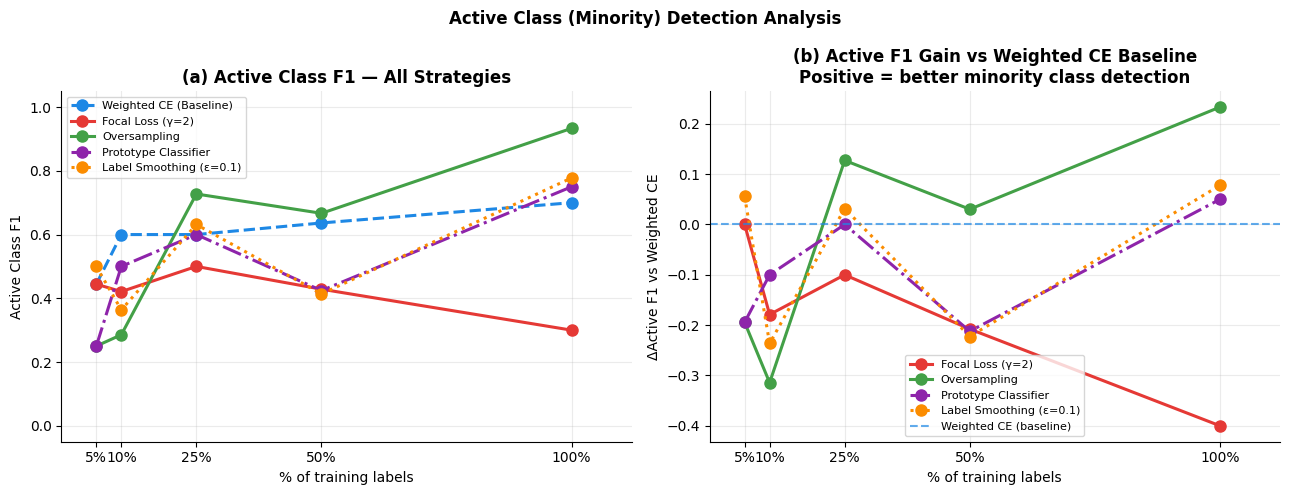

In [13]:
# Gain in Active F1 vs S1_WeightedCE (baseline)
baseline = results_df[results_df['Strategy']=='S1_WeightedCE'].set_index('Pct')['Active_F1']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Absolute Active F1 ────────────────────────────────────────────────────────
ax = axes[0]
for strat_id, strat_label in STRATEGIES.items():
    sub = results_df[results_df['Strategy']==strat_id].sort_values('Fraction')
    ax.plot(sub['Pct'], sub['Active_F1'],
            color=STRAT_COLORS[strat_id], linestyle=STRAT_LS[strat_id],
            linewidth=2.2, marker='o', markersize=8, label=strat_label)
ax.set_xlabel('% of training labels'); ax.set_ylabel('Active Class F1')
ax.set_title('(a) Active Class F1 — All Strategies', fontweight='bold')
ax.set_xticks([5,10,25,50,100])
ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%d%%'))
ax.set_xlim(-2,112); ax.set_ylim(-0.05,1.05)
ax.legend(fontsize=8); ax.grid(alpha=0.25); ax.spines[['top','right']].set_visible(False)

# ── Delta Active F1 vs baseline ───────────────────────────────────────────────
ax = axes[1]
for strat_id, strat_label in STRATEGIES.items():
    if strat_id == 'S1_WeightedCE': continue
    sub = results_df[results_df['Strategy']==strat_id].sort_values('Pct')
    delta = sub.set_index('Pct')['Active_F1'] - baseline
    ax.plot(delta.index, delta.values,
            color=STRAT_COLORS[strat_id], linestyle=STRAT_LS[strat_id],
            linewidth=2.2, marker='o', markersize=8, label=strat_label)

ax.axhline(0, color='#1E88E5', linewidth=1.5, linestyle='--', alpha=0.7, label='Weighted CE (baseline)')
ax.set_xlabel('% of training labels'); ax.set_ylabel('ΔActive F1 vs Weighted CE')
ax.set_title('(b) Active F1 Gain vs Weighted CE Baseline\nPositive = better minority class detection',
             fontweight='bold')
ax.set_xticks([5,10,25,50,100])
ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%d%%'))
ax.set_xlim(-2,112)
ax.legend(fontsize=8); ax.grid(alpha=0.25); ax.spines[['top','right']].set_visible(False)

plt.suptitle('Active Class (Minority) Detection Analysis', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('/kaggle/working/e4_fig5_active_gain.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 14 — Final Summary

In [14]:
print('='*68)
print('  EXPERIMENT 4 — CLASS IMBALANCE HANDLING SUMMARY')
print('  Model: ConvNeXt-Base  |  Focus: Active class (minority)')
print('='*68)

print('\n── Best strategy per fraction (Macro AUC) ──')
for pct in [5,10,25,50,100]:
    sub=results_df[results_df['Pct']==pct]
    if len(sub):
        row=sub.loc[sub['Test_AUC'].idxmax()]
        print(f'  {pct:3d}%  {STRATEGIES[row.Strategy]:28s}  '
              f'AUC={row.Test_AUC:.4f}  ActiveF1={row.Active_F1:.4f}')

print('\n── Best strategy per fraction (Active F1) ──')
for pct in [5,10,25,50,100]:
    sub=results_df[results_df['Pct']==pct]
    if len(sub):
        row=sub.loc[sub['Active_F1'].idxmax()]
        print(f'  {pct:3d}%  {STRATEGIES[row.Strategy]:28s}  '
              f'ActiveF1={row.Active_F1:.4f}  AUC={row.Test_AUC:.4f}  Recall={row.Active_Recall:.4f}')

print('\n── Full table @ 100% labels ──')
at100=results_df[results_df['Pct']==100].sort_values('Test_AUC',ascending=False)
print(at100[['StratLabel','Test_AUC','Test_MacroF1','Active_F1','Active_Recall','Ext_AUC']].to_string(index=False))

print('\n── Average Active F1 gain vs Weighted CE baseline ──')
base_avg=results_df[results_df['Strategy']=='S1_WeightedCE']['Active_F1'].mean()
for strat_id,strat_label in STRATEGIES.items():
    if strat_id=='S1_WeightedCE': continue
    avg=results_df[results_df['Strategy']==strat_id]['Active_F1'].mean()
    print(f'  {strat_label:28s}: mean ActiveF1={avg:.4f}  Δ={avg-base_avg:+.4f}')

print('\n── Clinical recommendation ──')
print('  For maximum Active class detection (clinical triage):')
best_active=results_df.loc[results_df['Active_F1'].idxmax()]
print(f'  → {STRATEGIES[best_active.Strategy]} at {best_active.Pct}% labels')
print(f'    ActiveF1={best_active.Active_F1:.4f}  Recall={best_active.Active_Recall:.4f}  AUC={best_active.Test_AUC:.4f}')

print('\n── Saved figures ──')
for f in sorted(Path('/kaggle/working').glob('e4_fig*.png')):
    print(f'  {f.name}')
print('  experiment4_results.csv')

  EXPERIMENT 4 — CLASS IMBALANCE HANDLING SUMMARY
  Model: ConvNeXt-Base  |  Focus: Active class (minority)

── Best strategy per fraction (Macro AUC) ──
    5%  Label Smoothing (ε=0.1)       AUC=0.9029  ActiveF1=0.5000
   10%  Label Smoothing (ε=0.1)       AUC=0.9423  ActiveF1=0.3636
   25%  Oversampling                  AUC=0.9816  ActiveF1=0.7273
   50%  Weighted CE (Baseline)        AUC=0.9833  ActiveF1=0.6364
  100%  Oversampling                  AUC=0.9866  ActiveF1=0.9333

── Best strategy per fraction (Active F1) ──
    5%  Label Smoothing (ε=0.1)       ActiveF1=0.5000  AUC=0.9029  Recall=0.7143
   10%  Weighted CE (Baseline)        ActiveF1=0.6000  AUC=0.9268  Recall=0.4286
   25%  Oversampling                  ActiveF1=0.7273  AUC=0.9816  Recall=0.5714
   50%  Oversampling                  ActiveF1=0.6667  AUC=0.9617  Recall=0.7143
  100%  Oversampling                  ActiveF1=0.9333  AUC=0.9866  Recall=1.0000

── Full table @ 100% labels ──
             StratLabel  Test_AUC